In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kurtosis
from scipy.stats import skew
np.random.seed(42)
sns.set_style("whitegrid")

# Task 1: Build and Summarize Synthetic Datasets
Start by creating three synthetic datasets that represent different distribution shapes. Each dataset should have 500 observations.

Dataset A — Symmetric: draw from a normal distribution with mean = 50 and standard deviation = 10.
Dataset B — Right-skewed: draw from an exponential distribution, then shift and scale so the values fall roughly in the 0–100 range.
Dataset C — Bimodal: combine two normal distributions (e.g., means at 30 and 70) with equal sample sizes.
For each dataset, compute and display in a summary table:

Mean, median, mode (rounded to 2 decimals)
Standard deviation, variance, IQR
Skewness and kurtosis (use scipy.stats.skew and scipy.stats.kurtosis)
Guiding question: Which summary statistics look similar across the three datasets, and which reveal the differences?

In [4]:
data_a = np.random.normal(loc=50, scale=10, size=500)
data_b = np.random.exponential(scale=1, size=500)
data_b = (data_b - data_b.min()) / (data_b.max() - data_b.min()) * 100
data_c_part1 = np.random.normal(loc=30, scale=5, size=250)
data_c_part2 = np.random.normal(loc=70, scale=5, size=250)
data_c = np.concatenate([data_c_part1, data_c_part2])

In [58]:
data_a_sum = pd.Series(data_a, name='data_a_summary').describe().round(2)

In [60]:
data_b_sum = pd.Series(data_b, name='data_b_summary').describe().round(2)

In [90]:
data_c_sum = pd.Series(data_c, name='data_c_summary').describe().round(2)

In [92]:
print(
    f"Dataset A Summary:\n{data_a_sum}\n"
    f"{'='*30}\n"
    f"Dataset B Summary:\n{data_b_sum}\n"
    f"{'='*30}\n"
    f"Dataset C Summary:\n{data_c_sum}"
)

Dataset A Summary:
count    500.00
mean      50.07
std        9.81
min       17.59
25%       43.00
50%       50.13
75%       56.37
max       88.53
Name: data_a_summary, dtype: float64
Dataset B Summary:
count    500.00
mean      16.17
std       15.99
min        0.00
25%        4.29
50%       11.29
75%       22.94
max      100.00
Name: data_b_summary, dtype: float64
Dataset C Summary:
count    500.00
mean      50.33
std       20.30
min       15.52
25%       30.97
50%       49.53
75%       69.98
max       82.90
Name: data_c_summary, dtype: float64


In [56]:
iqr_a = np.percentile(data_a, 75) - np.percentile(data_a, 25)
iqr_b = np.percentile(data_b, 75) - np.percentile(data_b, 25)
iqr_c = np.percentile(data_c, 75) - np.percentile(data_c, 25)
print(f"IQR of Dataset A: {iqr_a:.2f}")
print(f"IQR of Dataset B: {iqr_b:.2f}")
print(f"IQR of Dataset C: {iqr_c:.2f}")

IQR of Dataset A: 13.37
IQR of Dataset B: 18.65
IQR of Dataset C: 39.01


In [16]:
print(f"Right-skewed kurtosis: {kurtosis(data_b):.2f}")
print(f"Symmetric kurtosis:    {kurtosis(data_a):.2f}")
print(f"Bimodal kurtosis:    {kurtosis(data_c):.2f}")


Right-skewed kurtosis: 3.98
Symmetric kurtosis:    0.26
Bimodal kurtosis:    -1.76


In [22]:
print(f"Right-skewed data: skewness = {skew(data_b):.2f}")
print(f"Symmetric data:    skewness = {skew(data_a):.2f}")
print(f"Bimodal data:  skewness = {skew(data_c):.2f}")

Right-skewed data: skewness = 1.77
Symmetric data:    skewness = 0.18
Bimodal data:  skewness = 0.01


### Summary of Dataset Statistics

**Count:** All datasets = 500 — identical by design.

**Mean (Dataset A vs C):** A: 50.07, C: 50.33 — very similar despite different shapes.  
**Median (Dataset A vs C):** A: 50.13, C: 49.53 — also similar; mean and median hide the bimodality of Dataset C.

**Standard Deviation:** A: 9.81, B: 15.99, C: 20.30 — Dataset C has the largest spread due to two peaks.  
**IQR:** A: 13.37, B: 18.65, C: 39.01 — confirms wide dispersion in Dataset C.  
**Skewness:** A: 0.18, B: 1.77, C: 0.01 — B is right-skewed, C appears symmetric but is bimodal.  
**Kurtosis:** A: 0.26, B: 3.98, C: -1.76 — B has heavy tails, C is flatter.  
**Quartiles:**  
- A: Q1=43, Q3=56 — tight around center  
- B: Q1=4, Q3=22 — compressed with long right tail  
- C: Q1=30, Q3=70 — widely separated, showing two clusters

**Key insight:** Mean and median can be misleading; standard deviation, IQR, skewness, kurtosis, and quartiles better reveal differences between symmetric, right-skewed, and bimodal distributions.

# Task 2: Visualize the Distributions
Create a figure with three rows and three columns (9 subplots total). Each row represents one dataset (A, B, C). The columns are:

Histogram with 30 bins and a KDE overlay.
Boxplot (horizontal orientation).
KDE plot alone, with vertical lines marking the mean (dashed red) and median (solid blue).
Add clear titles and axis labels to every subplot. Use plt.tight_layout() to prevent overlap.

Guiding question: For which dataset(s) do the mean and median diverge the most? What visual feature explains the divergence?

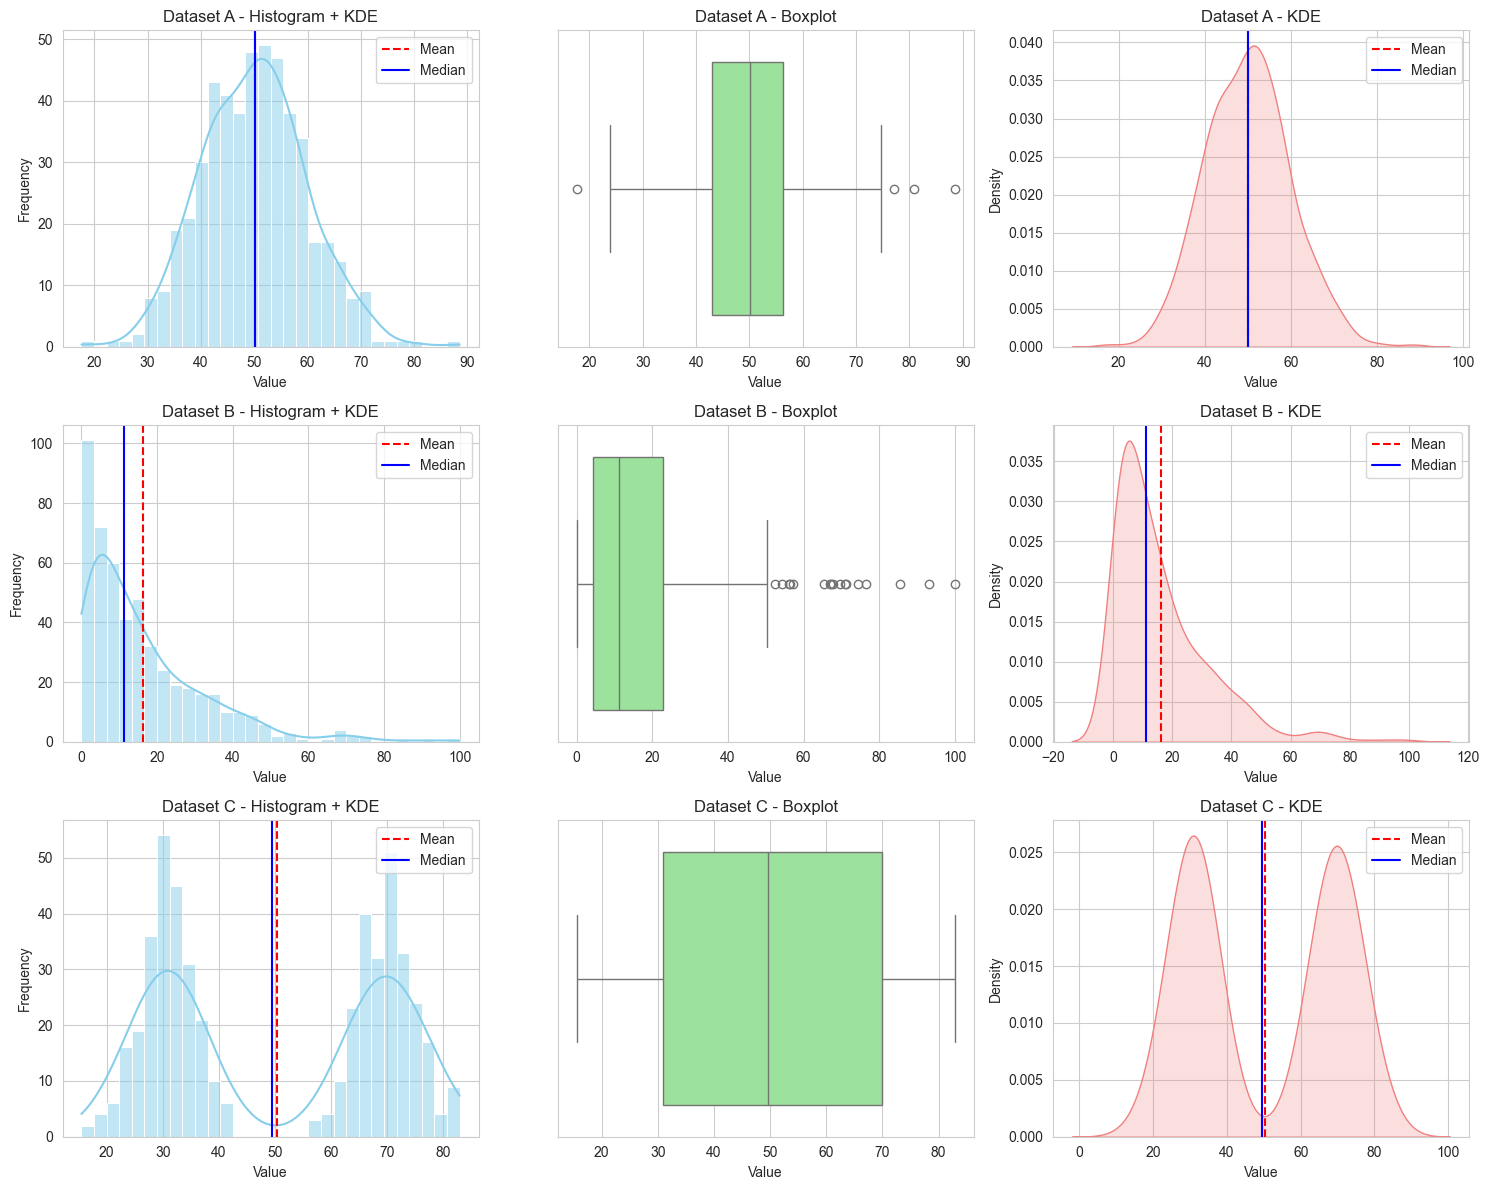

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # axes[0] ... axes[8]

# -----------------------
# First row: Dataset A
# -----------------------
# Histogram + KDE
sns.histplot(data_a, bins=30, kde=True, ax=axes[0], color='skyblue', edgecolor='white')
axes[0].axvline(np.mean(data_a), color="red", linestyle="--", label="Mean")
axes[0].axvline(np.median(data_a), color="blue", linestyle="-", label="Median")
axes[0].set_title("Dataset A - Histogram + KDE")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot
sns.boxplot(x=data_a, ax=axes[1], color='lightgreen', orient='h')
axes[1].set_title("Dataset A - Boxplot")
axes[1].set_xlabel("Value")

# KDE alone
sns.kdeplot(data_a, ax=axes[2], fill=True, color='lightcoral')
axes[2].axvline(np.mean(data_a), color="red", linestyle="--", label="Mean")
axes[2].axvline(np.median(data_a), color="blue", linestyle="-", label="Median")
axes[2].set_title("Dataset A - KDE")
axes[2].set_xlabel("Value")
axes[2].set_ylabel("Density")
axes[2].legend()

# -----------------------
# Second row: Dataset B
# -----------------------
sns.histplot(data_b, bins=30, kde=True, ax=axes[3], color='skyblue', edgecolor='white')
axes[3].axvline(np.mean(data_b), color="red", linestyle="--", label="Mean")
axes[3].axvline(np.median(data_b), color="blue", linestyle="-", label="Median")
axes[3].set_title("Dataset B - Histogram + KDE")
axes[3].set_xlabel("Value")
axes[3].set_ylabel("Frequency")
axes[3].legend()

sns.boxplot(x=data_b, ax=axes[4], color='lightgreen', orient='h')
axes[4].set_title("Dataset B - Boxplot")
axes[4].set_xlabel("Value")

sns.kdeplot(data_b, ax=axes[5], fill=True, color='lightcoral')
axes[5].axvline(np.mean(data_b), color="red", linestyle="--", label="Mean")
axes[5].axvline(np.median(data_b), color="blue", linestyle="-", label="Median")
axes[5].set_title("Dataset B - KDE")
axes[5].set_xlabel("Value")
axes[5].set_ylabel("Density")
axes[5].legend()

# -----------------------
# Third row: Dataset C
# -----------------------
sns.histplot(data_c, bins=30, kde=True, ax=axes[6], color='skyblue', edgecolor='white')
axes[6].axvline(np.mean(data_c), color="red", linestyle="--", label="Mean")
axes[6].axvline(np.median(data_c), color="blue", linestyle="-", label="Median")
axes[6].set_title("Dataset C - Histogram + KDE")
axes[6].set_xlabel("Value")
axes[6].set_ylabel("Frequency")
axes[6].legend()

sns.boxplot(x=data_c, ax=axes[7], color='lightgreen', orient='h')
axes[7].set_title("Dataset C - Boxplot")
axes[7].set_xlabel("Value")

sns.kdeplot(data_c, ax=axes[8], fill=True, color='lightcoral')
axes[8].axvline(np.mean(data_c), color="red", linestyle="--", label="Mean")
axes[8].axvline(np.median(data_c), color="blue", linestyle="-", label="Median")
axes[8].set_title("Dataset C - KDE")
axes[8].set_xlabel("Value")
axes[8].set_ylabel("Density")
axes[8].legend()

plt.tight_layout()
plt.show()

**Guiding Question Answer:**

The mean and median diverge the most in **Dataset B (Right-skewed)**.  
- In **Dataset A (Symmetric)**, the mean and median are approximately equal, so no noticeable divergence appears in the histogram or KDE plots.  
- In **Dataset B**, the histogram and KDE show a **long right tail**, which pulls the mean toward higher values while the median remains near the bulk of the data. This **skewed distribution** explains why the mean is larger than the median.  
- **Dataset C (Bimodal)** has a roughly symmetric shape around the center, so the mean and median are close, even though the data has two peaks.  

In [102]:
data_a_mod = data_a.copy()
# Replace 5 largest values with extreme outliers (multiply by 10)
largest_indices = np.argsort(data_a_mod)[-5:]  # indices of 5 largest values
data_a_mod[largest_indices] = data_a_mod[largest_indices] * 10
# Optional: check the modified values
print("Modified outlier values:", data_a_mod[largest_indices])

Modified outlier values: [731.46585667 746.32421125 772.01691666 807.88808085 885.27314907]


In [104]:
# Create DataFrames
summary_orig = pd.Series(data_a, name='Original').describe().round(2)
summary_mod  = pd.Series(data_a_mod,  name='Modified').describe().round(2)
# Combine for side-by-side view
summary_table = pd.concat([summary_orig, summary_mod], axis=1)
summary_table

,Original,Modified
count,500.00,500.00
mean,50.07,57.17
std,9.81,74.38
min,17.59,17.59
25%,43.00,43.00
50%,50.13,50.13
75%,56.37,56.37
max,88.53,885.27


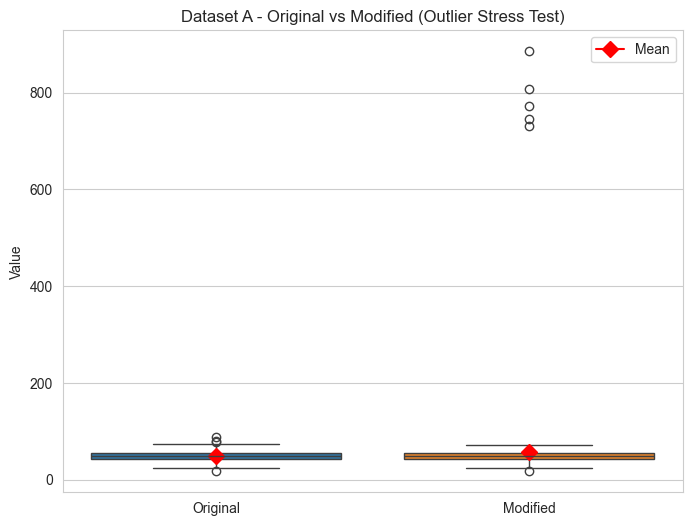

In [106]:
plt.figure(figsize=(8,6))

# Combine datasets into a list for plotting
datasets = [data_a, data_a_mod]
labels = ['Original', 'Modified']

# Boxplot
sns.boxplot(data=datasets)
plt.xticks([0,1], labels)

# Overlay mean as diamond marker
means = [np.mean(data_a), np.mean(data_a_mod)]
for i, m in enumerate(means):
    plt.plot(i, m, marker='D', color='red', markersize=8, label='Mean' if i==0 else "")

plt.title("Dataset A - Original vs Modified (Outlier Stress Test)")
plt.ylabel("Value")
plt.legend()
plt.show()

The mean, max, and standard deviation changed a lot when we added the big outliers.  
The median and IQR didn’t change at all, so they are more reliable.  
If I had to report a “typical” value for this modified dataset, I’d go with the median because the mean gets pulled up by the extreme values.